# P1: CPP signature

**The key AAanalysis protocol.** This workflow finds the physicochemical differences between two protein sets. Given two labelled sets of protein sequences (e.g. substrates vs. non-substrates, binders vs. non-binders, toxic vs. non-toxic), *Comparative Physicochemical Profiling* (CPP) identifies the set of position-resolved physicochemical features that most distinctly separate them, a **determinant-discovery** task that needs no black-box model. We call this feature set the **signature** of the test group.

> **Key mental model.** CPP contrasts a **test group** (`label=1`) against a **reference group** (`label=0`) and reads out *what physicochemically distinguishes them, and where*. Behind the scenes it splits each sequence into **parts**, applies **splits** (position selectors) within each part, averages an amino-acid **scale** over those positions, and keeps the `Part-Split-Scale` features that separate the two groups best. The result is interpretable biology (an AAontology-grounded **signature**), not a black box you have to trust on faith.

**When to use it.** Use this protocol when you have **two labelled sets of sequences** and want to answer: *"Which physicochemical patterns distinguish my groups, and where in the sequence do they act?"*, without first committing to a black-box model. In glossary terms this is **determinant discovery**: contrast a **test group** (`label=1`) against a **reference group** (`label=0`) and read out *what physicochemically distinguishes them*.

Typical questions: substrate vs. non-substrate, cleaved vs. not cleaved, aggregation-prone vs. soluble, toxic vs. non-toxic.

Here we work at the **domain level** (dataset prefix `DOM_`): the unit of comparison is the transmembrane-domain (TMD) **part** set, native ground for CPP.

**When *not* to use it.** CPP needs two *labelled* groups to contrast. If you have no labels and just want to explore one set of sequences, start with *Protocol 0: Exploratory sequence analysis* instead. If you already trust a classifier and only want to know *why it called this one protein positive*, that is a per-sample explanation task (see *Protocol 8: Interpretability*, `ShapModel`). And CPP profiles part **segments**, not long-range residue-residue contacts or inter-chain interfaces; those are a documented scope boundary and belong to structure / PLM tooling.

**Input.** A `df_seq` with one row per protein and a binary `label` column (test class = 1 vs. reference class = 0). For a **domain-level** task it also carries `tmd_start` / `tmd_stop` (1-based, start- and stop-**inclusive**), from which CPP derives the **TMD-centric parts** `jmd_n` / `tmd` / `jmd_c`. This default part vocabulary fits a domain-level task where the unit *is* a TMD; for another domain you would rename the central `tmd` part to the specific domain name (e.g. its Pfam/InterPro domain).

Here we use the bundled `DOM_GSEC` gamma-secretase dataset. The bridge from sequences to CPP is `SequenceFeature.get_df_parts`, which turns `df_seq` into the `df_parts` that `CPP` consumes.

For a residue/window task you would construct windows first (see *Protocol 3: Construct sets & sampling*); for embeddings/structure see *Protocol 4: Engineer features* (`CPP.run_num`).

In [1]:
import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Two labelled sets of sequences (label: 1 = substrate/test, 0 = reference)
df_seq = aa.load_dataset(name="DOM_GSEC", n=50)
labels = df_seq["label"].to_list()
aa.display_df(df=df_seq, n_rows=5)

,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
1,Q14802,MQKVTLGLLVFLAGF...PGETPPLITPGSAQS,0,37,59,NSPFYYDWHS,LQVGGLICAGVLCAMGIIIVMSA,KCKCKFGQKS
2,Q86UE4,MAARSWQDELAQQAE...SPKQIKKKKKARRET,0,50,72,LGLEPKRYPG,WVILVGTGALGLLLLFLLGYGWA,AACAGARKKR
3,Q969W9,MHRLMGVNSTAAAAA...AIWSKEKDKQKGHPL,0,41,63,FQSMEITELE,FVQIIIIVVVMMVMVVVITCLLS,HYKLSARSFI
4,P53801,MAPGVARGPTPYWRL...GLFKEENPYARFENN,0,97,119,RWGVCWVNFE,ALIITMSVVGGTLLLGIAICCCC,CCRRKRSRKP
5,Q8IUW5,MAPRALPGSAVLAAA...EVPATPVKRERSGTE,0,59,81,NDTGNGHPEY,IAYALVPVFFIMGLFGVLICHLL,KKKGYRCTTE


**Run.** The **real** minimal path (not a one-liner): build sequence *parts* with `SequenceFeature`, construct `CPP` on those parts and call `run` with the labels, then rank the resulting signature by importance with a `TreeModel`. `CPP()` takes `df_parts`, it does **not** take `df_seq`/`labels` directly. (See the CPP tutorial `tutorial3c_cpp` for the function details and parameters.)

In [2]:
# 1) Split each sequence into parts (TMD / JMD-N / JMD-C by default)
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)

# 2) Run CPP on the parts to obtain the most discriminant features
#    (n_jobs=1 keeps it serial; multiprocessing spawn is fragile on
#    Python 3.14 + macOS without a __main__ guard)
cpp = aa.CPP(df_parts=df_parts)
df_feat = cpp.run(labels=labels, n_filter=50, n_jobs=1)
aa.display_df(df=df_feat, n_rows=8)

,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions
1,"TMD_C_JMD_C-Seg...2,3)-QIAN880106",Conformation,α-helix,α-helix (middle),"Weights for alp...ejnowski, 1988)",0.387000,0.121000,0.121000,0.069000,0.085000,0.000000,0.000001,"27,28,29,30,31,32,33"
2,"TMD_C_JMD_C-Seg...5,7)-FAUJ880104",Shape,Side chain length,Steric parameter,"STERIMOL length...e et al., 1988)",0.382000,0.264000,0.264000,0.156000,0.156000,0.000000,0.000001,"32,33,34"
3,"TMD_C_JMD_C-Pat...,12)-ROBB760109",Conformation,β-turn (N-term),β-turn (1st residue),"Information mea...n-Suzuki, 1976)",0.377000,0.127000,-0.127000,0.062000,0.088000,0.000000,0.000001,"21,25,28,32"
4,"TMD_C_JMD_C-Seg...4,5)-ZIMJ680104",Energy,Isoelectric point,Isoelectric point,"Isoelectric poi...n et al., 1968)",0.373000,0.220000,0.220000,0.124000,0.137000,0.000000,0.000001,"33,34,35,36"
5,"TMD_C_JMD_C-Seg...5,7)-ONEK900101",Others,Unclassified (Others),ΔG values in peptides,"Delta G values ...-DeGrado, 1990)",0.373000,0.115000,0.115000,0.066000,0.113000,0.000000,0.000001,"32,33,34"
6,"TMD_C_JMD_C-Seg...4,5)-WOLS870103",Others,PC 4,Principal Component 3 (Wold),"Principal prope...d et al., 1987)",0.370000,0.218000,-0.218000,0.123000,0.169000,0.000000,0.000001,"33,34,35,36"
7,"TMD_C_JMD_C-Seg...2,3)-WOLS870103",Others,PC 4,Principal Component 3 (Wold),"Principal prope...d et al., 1987)",0.365000,0.154000,-0.154000,0.096000,0.123000,0.000000,0.000001,"27,28,29,30,31,32,33"
8,"TMD_C_JMD_C-Seg...4,5)-FINA910103",Conformation,α-helix (C-cap),"α-helix (C-terminal, inside)","Helix terminati...n et al., 1991)",0.362000,0.264000,0.264000,0.157000,0.175000,0.000000,0.000001,"33,34,35,36"


In [3]:
# 3) Rank the signature by importance: fit a tree on the CPP feature
#    matrix, then add the Monte-Carlo feature importance (percent) as
#    a new column. This is a group-level, unsigned ranking signal.
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)
tm = aa.TreeModel()
tm = tm.fit(X, labels=labels)
df_feat = tm.add_feat_importance(df_feat=df_feat)
aa.display_df(df=df_feat[["feature", "category", "subcategory", "mean_dif", "abs_auc", "feat_importance"]], n_rows=8)

,feature,category,subcategory,mean_dif,abs_auc,feat_importance
1,"TMD_C_JMD_C-Seg...2,3)-QIAN880106",Conformation,α-helix,0.121000,0.387000,4.527000
2,"TMD_C_JMD_C-Seg...5,7)-FAUJ880104",Shape,Side chain length,0.264000,0.382000,4.462000
3,"TMD_C_JMD_C-Pat...,12)-ROBB760109",Conformation,β-turn (N-term),-0.127000,0.377000,5.282000
4,"TMD_C_JMD_C-Seg...4,5)-ZIMJ680104",Energy,Isoelectric point,0.220000,0.373000,3.031000
5,"TMD_C_JMD_C-Seg...5,7)-ONEK900101",Others,Unclassified (Others),0.115000,0.373000,1.911000
6,"TMD_C_JMD_C-Seg...4,5)-WOLS870103",Others,PC 4,-0.218000,0.370000,1.865000
7,"TMD_C_JMD_C-Seg...2,3)-WOLS870103",Others,PC 4,-0.154000,0.365000,2.154000
8,"TMD_C_JMD_C-Seg...4,5)-FINA910103",Conformation,α-helix (C-cap),0.264000,0.362000,2.285000


**Output.** `df_feat` is the **signature**: one row per selected feature. Each feature is one `Part-Split-Scale` combination, *where* in the sequence (part), *how* the positions are selected (split), and *which* physicochemical property is averaged (scale). Key columns:

- `feature`: the `Part-Split-Scale` identifier.
- `category` / `subcategory`: the AAontology property group.
- `mean_dif`: mean difference (test minus reference); the **sign** gives the direction.
- `abs_auc`: effect size / separation strength of the feature.
- `feat_importance`: tree-based importance (percent), used to rank the signature.

Visualise the whole signature as a feature map:

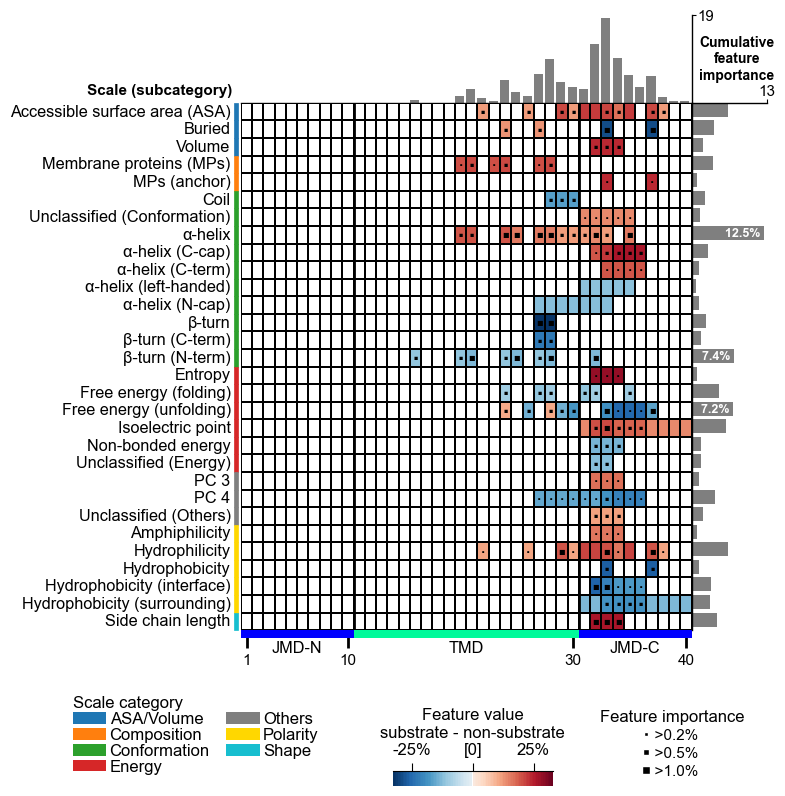

In [4]:
import matplotlib.pyplot as plt

cpp_plot = aa.CPPPlot()                 # feature_map is an INSTANCE method
aa.plot_settings(font_scale=0.65, weight_bold=False)
cpp_plot.feature_map(df_feat=df_feat, name_test="substrate", name_ref="non-substrate")
plt.tight_layout()
plt.show()

**How to interpret.** A few things to read off the feature map:

| Output | Non-expert reading |
| --- | --- |
| high `abs_auc` | strong group-separating property |
| positive `mean_dif` | property is **higher** in the test group in that region |
| negative `mean_dif` | property is **higher** in the reference group |
| a positional feature (e.g. `Segment(2,3)` / `Pattern(...)`) | the signal depends on *where* in the part it occurs |
| a whole-part `Segment(1,1)` feature | a **compositional** (position-agnostic) difference |
| a subcategory dominating the map | that property family drives the separation |

Read the feature map as: *rows = physicochemical properties (scale subcategories), columns = positions along the parts, colour = direction & strength of the difference, top bars = cumulative feature importance.* A robust signature shows coherent blocks, not scattered single cells.

Because every scale belongs to an **AAontology** category/subcategory, the signature reads as biology: a coherent block of high-`abs_auc` features from one subcategory localised to a given part (e.g. the `tmd`) says *that* property family, *there*, is what physicochemically distinguishes the test group from the reference.

**Key takeaways**

- The signature is the *set* of `Part-Split-Scale` features, not any single row: interpret coherent **blocks** (one subcategory, one region), and note whether they are **compositional** (whole-part) or **positional** (sub-region/pattern).
- `mean_dif` carries the **direction** (test minus reference) and `abs_auc` the **effect size**; `feat_importance` is an unsigned, group-level ranking signal: three complementary axes, not duplicates.
- A signature describes *what separates the groups in this dataset*; it is a hypothesis about determinants, so confirm stability before drawing biological conclusions.

**Common mistakes.**

- **Calling `CPP(df_seq=...)` or `CPP().run(df_seq, labels)`**: `CPP` takes `df_parts`; build them with `SequenceFeature.get_df_parts` first.
- **Treating `CPPPlot.feature_map` as static**: it is an *instance* method (`aa.CPPPlot().feature_map(...)`), and it needs a `feat_importance` column (add it with `TreeModel.add_feat_importance`).
- **Over-reading a single feature**: interpret the *signature* (blocks of related features), and check stability before drawing biological conclusions (see *Protocol 9: Validate*).
- **Using `len(df_seq)` for class sizes**: use the `label` column; `load_dataset(..., n=N)` returns `2N` rows (N per class).

**Next step.** Continue with *P2: Exploratory sequence analysis* to explore one set of sequences without labels before contrasting groups.